In [75]:
model_results = pd.read_csv("../outputs/model_comparison.csv")

model_results

,Model,ROC_AUC,ROC_AUC_STD
0,Logistic Regression,0.847274,0.004161
1,Random Forest,0.829359,0.004643
2,XGBoost,0.843605,0.003615


In [70]:
from sklearn.model_selection import train_test_split

X = data.drop(
    columns=["customerID", "Churn", "Churn_Target"],
    errors="ignore"
)

y = data["Churn_Target"]

X = pd.get_dummies(
    X,
    drop_first=True
)

X = X.reindex(
    columns=model_features,
    fill_value=0
)

X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (5625, 38)
X_test: (1407, 38)


In [ ]:
import pandas as pd
import json

data = pd.read_csv("../data/processed/customer_master.csv")

with open("../outputs/model_features.json", "r") as f:
    model_features = json.load(f)

print("Dataset shape:", data.shape)
print("Number of model features:", len(model_features))



Dataset shape: (7032, 27)
Number of model features: 38


In [67]:
import joblib

joblib.dump(
    calibrated_model,
    "../outputs/calibrated_xgboost_model.pkl"
)

print("Calibrated XGBoost model saved.")

Calibrated XGBoost model saved.


In [66]:
# Generate calibrated churn probabilities
data["Churn_Probability"] = calibrated_model.predict_proba(
    X_calibration
)[:, 1]

print(data["Churn_Probability"].describe())

data["Risk_Band"] = pd.cut(
    data["Churn_Probability"],
    bins=[0, 0.30, 0.60, 0.80, 1.00],
    labels=["Low", "Medium", "High", "Critical"],
    include_lowest=True
)

data["Risk_Band"] = pd.cut(
    data["Churn_Probability"],
    bins=[0, 0.30, 0.60, 0.80, 1.00],
    labels=["Low", "Medium", "High", "Critical"],
    include_lowest=True
)

data["Retention_Priority_Score"] = (
    data["Churn_Probability"] *
    data["Normalized_Value"]
)

priority_customers = (
    data
    .sort_values(
        "Retention_Priority_Score",
        ascending=False
    )
)

priority_customers.to_csv(
    "../outputs/customer_risk_scores.csv",
    index=False
)

print("Updated calibrated customer risk scores saved.")

count    7032.000000
mean        0.267143
std         0.248347
min         0.056664
25%         0.069104
50%         0.143352
75%         0.417466
max         0.907638
Name: Churn_Probability, dtype: float64
Updated calibrated customer risk scores saved.


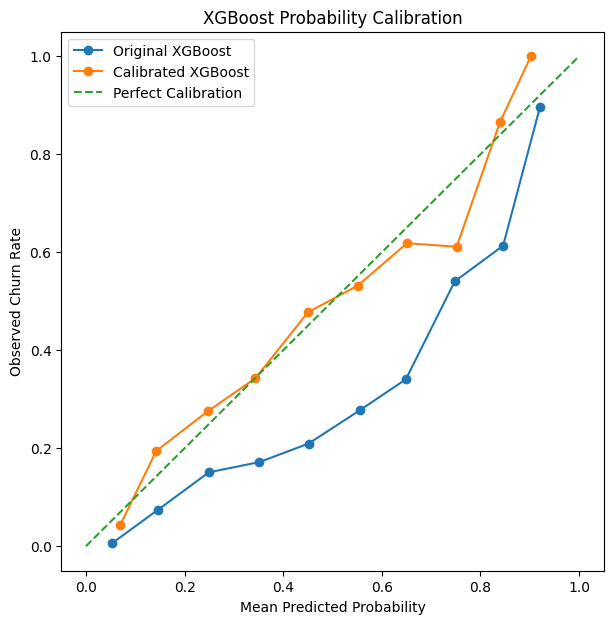

In [61]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Original
prob_true_original, prob_pred_original = calibration_curve(
    y_test,
    test_probabilities,
    n_bins=10
)

# Calibrated
prob_true_calibrated, prob_pred_calibrated = calibration_curve(
    y_test,
    calibrated_probabilities,
    n_bins=10
)

plt.figure(figsize=(7, 7))

plt.plot(
    prob_pred_original,
    prob_true_original,
    marker="o",
    label="Original XGBoost"
)

plt.plot(
    prob_pred_calibrated,
    prob_true_calibrated,
    marker="o",
    label="Calibrated XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Churn Rate")
plt.title("XGBoost Probability Calibration")
plt.legend()
plt.show()

In [60]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
calibrated_model = CalibratedClassifierCV(
    best_model,
    method="sigmoid",
    cv=5
)

calibrated_model.fit(
    X_train,
    y_train
)

calibrated_probabilities = calibrated_model.predict_proba(
    X_test
)[:, 1]
original_brier = brier_score_loss(
    y_test,
    test_probabilities
)

calibrated_brier = brier_score_loss(
    y_test,
    calibrated_probabilities
)

print("Original XGBoost Brier Score:", original_brier)
print("Calibrated XGBoost Brier Score:", calibrated_brier)

Original XGBoost Brier Score: 0.17051569280047366
Calibrated XGBoost Brier Score: 0.13818274645357756


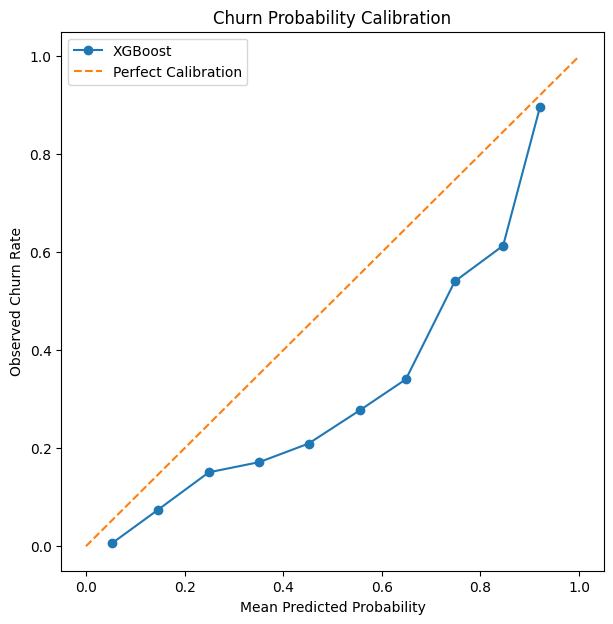

In [59]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

test_probabilities = best_model.predict_proba(
    X_test
)[:, 1]

prob_true, prob_pred = calibration_curve(
    y_test,
    test_probabilities,
    n_bins=10
)

plt.figure(figsize=(7, 7))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Churn Rate")
plt.title("Churn Probability Calibration")
plt.legend()
plt.show()

In [56]:
from sklearn.model_selection import train_test_split

# Target
y = data["Churn_Target"]

# Features
X_calibration = data.drop(
    columns=["customerID", "Churn", "Churn_Target"],
    errors="ignore"
)

# Convert categorical variables
X_calibration = pd.get_dummies(
    X_calibration,
    drop_first=True
)

# Match the exact features used by the trained model
X_calibration = X_calibration.reindex(
    columns=model_features,
    fill_value=0
)

# Fill missing values
X_calibration = X_calibration.fillna(0)

# Create test set
X_train, X_test, y_train, y_test = train_test_split(
    X_calibration,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (1407, 38)
y_test shape: (1407,)


In [55]:
import json

with open("../outputs/model_features.json", "r") as f:
    model_features = json.load(f)

print("Number of model features:", len(model_features))
print("First 10 features:", model_features[:10])

Number of model features: 38
First 10 features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Service_Count', 'Estimated_Billed_Value', 'Charge_per_Tenure_Month', 'Streaming_Adoption', 'gender_Male', 'Partner_Yes']


In [48]:
priority_customers[
    [
        "customerID",
        "Contract",
        "tenure",
        "MonthlyCharges",
        "Churn_Probability",
        "Risk_Band",
        "Estimated_Billed_Value",
        "Expected_Revenue_at_Risk",
        "Retention_Segment"
    ]
].head(100).to_csv(
    "../outputs/top_100_retention_targets.csv",
    index=False
)

print("Top 100 retention targets saved.")

Top 100 retention targets saved.


In [41]:
data.to_csv(
    "../outputs/customer_risk_scores.csv",
    index=False
)

segment_summary.to_csv(
    "../outputs/retention_segment_summary.csv"
)

strategy_results.to_csv(
    "../outputs/retention_strategy_comparison.csv",
    index=False
)

print("All risk-scoring outputs saved successfully.")

All risk-scoring outputs saved successfully.


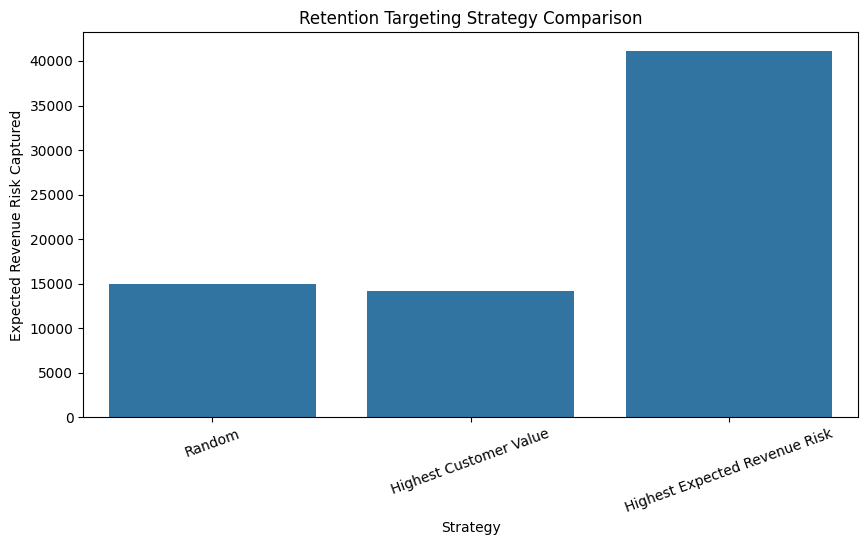

In [40]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=strategy_results,
    x="Strategy",
    y="Expected Revenue Risk Captured"
)

plt.title(
    "Retention Targeting Strategy Comparison"
)

plt.xlabel("Strategy")
plt.ylabel(
    "Expected Revenue Risk Captured"
)

plt.xticks(rotation=20)

plt.show()

In [39]:
random_sample = data.sample(
    RETENTION_CAPACITY,
    random_state=42
)

random_risk = (
    random_sample[
        "Expected_Revenue_at_Risk"
    ].sum()
)

value_sample = (
    data
    .sort_values(
        "Estimated_Billed_Value",
        ascending=False
    )
    .head(RETENTION_CAPACITY)
)

value_risk = (
    value_sample[
        "Expected_Revenue_at_Risk"
    ].sum()
)

risk_sample = (
    data
    .sort_values(
        "Expected_Revenue_at_Risk",
        ascending=False
    )
    .head(RETENTION_CAPACITY)
)

risk_based_risk = (
    risk_sample[
        "Expected_Revenue_at_Risk"
    ].sum()
)

strategy_results = pd.DataFrame({
    "Strategy": [
        "Random",
        "Highest Customer Value",
        "Highest Expected Revenue Risk"
    ],
    "Expected Revenue Risk Captured": [
        random_risk,
        value_risk,
        risk_based_risk
    ]
})

strategy_results

,Strategy,Expected Revenue Risk Captured
0,Random,14973.267588
1,Highest Customer Value,14138.788314
2,Highest Expected Revenue Risk,41158.541489


In [35]:
RETENTION_CAPACITY = 500
top_risk = (
    data
    .sort_values(
        "Expected_Revenue_at_Risk",
        ascending=False
    )
    .head(RETENTION_CAPACITY)
)

captured_revenue_risk = (
    top_risk["Expected_Revenue_at_Risk"]
    .sum()
)

coverage = (
    captured_revenue_risk
    /
    total_revenue_risk
)

print(
    f"Top {RETENTION_CAPACITY} customers capture "
    f"{coverage:.2%} of modeled revenue risk."
)

Top 500 customers capture 19.31% of modeled revenue risk.


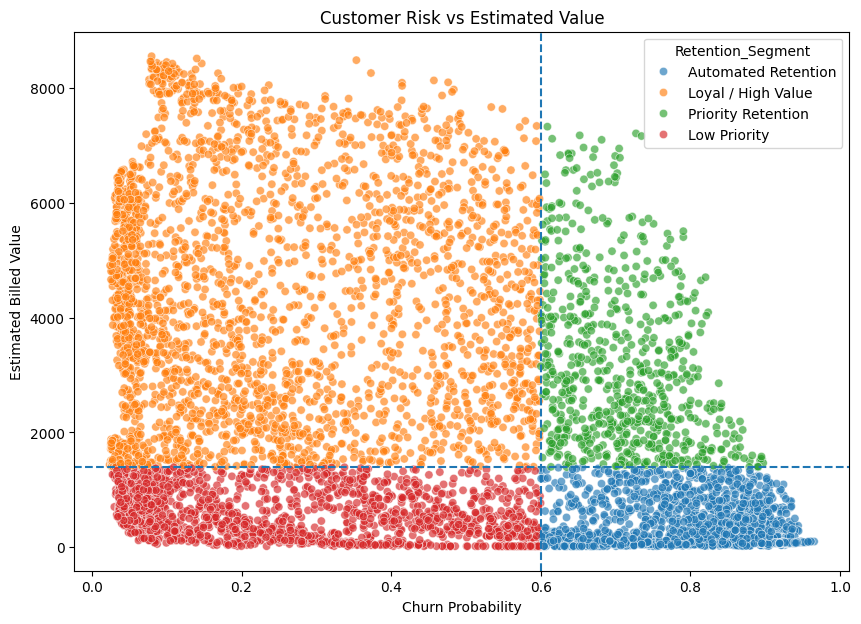

In [34]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=data,
    x="Churn_Probability",
    y="Estimated_Billed_Value",
    hue="Retention_Segment",
    alpha=0.65
)

plt.axvline(
    0.60,
    linestyle="--"
)

plt.axhline(
    value_median,
    linestyle="--"
)

plt.title(
    "Customer Risk vs Estimated Value"
)

plt.xlabel("Churn Probability")
plt.ylabel("Estimated Billed Value")

plt.show()

In [33]:
segment_summary = (
    data
    .groupby("Retention_Segment")
    .agg(
        Customers=("customerID", "count"),
        Avg_Churn_Risk=("Churn_Probability", "mean"),
        Total_Revenue_Risk=(
            "Expected_Revenue_at_Risk",
            "sum"
        ),
        Avg_Monthly_Charge=(
            "MonthlyCharges",
            "mean"
        )
    )
    .sort_values(
        "Total_Revenue_Risk",
        ascending=False
    )
)

segment_summary

,Customers,Avg_Churn_Risk,Total_Revenue_Risk,Avg_Monthly_Charge
Retention_Segment,,,,
Automated Retention,1582,0.806606,89908.295878,69.135430
Loyal / High Value,2788,0.237157,56649.310441,77.949354
Priority Retention,728,0.709572,48461.153363,93.583585
Low Priority,1934,0.247867,18124.180940,31.456618


In [32]:
value_median = data[
    "Estimated_Billed_Value"
].median()

data["High_Value"] = (
    data["Estimated_Billed_Value"]
    >= value_median
)

data["High_Risk"] = (
    data["Churn_Probability"]
    >= 0.60
)

def retention_segment(row):

    if row["High_Value"] and row["High_Risk"]:
        return "Priority Retention"

    elif not row["High_Value"] and row["High_Risk"]:
        return "Automated Retention"

    elif row["High_Value"] and not row["High_Risk"]:
        return "Loyal / High Value"

    else:
        return "Low Priority"


data["Retention_Segment"] = (
    data.apply(
        retention_segment,
        axis=1
    )
)

In [28]:
data["Retention_Priority_Score"] = (
    data["Churn_Probability"]
    *
    data["Normalized_Value"]
)

priority_customers = (
    data
    .sort_values(
        "Retention_Priority_Score",
        ascending=False
    )
)

priority_customers[
    [
        "customerID",
        "Churn_Probability",
        "Risk_Band",
        "MonthlyCharges",
        "Estimated_Billed_Value",
        "Expected_Revenue_at_Risk",
        "Retention_Priority_Score"
    ]
].head(20)

,customerID,Churn_Probability,Risk_Band,MonthlyCharges,Estimated_Billed_Value,Expected_Revenue_at_Risk,Retention_Priority_Score
6023,9090-SGQXL,0.734604,High,105.30,7160.40,77.353751,0.614948
2874,4550-VBOFE,0.727275,High,102.95,7206.50,74.872950,0.612743
3777,1469-LBJQJ,0.704736,High,105.20,6943.20,74.138195,0.572003
2272,3571-RFHAR,0.681347,High,109.15,7094.75,74.369013,0.565123
6371,2378-VTKDH,0.705783,High,104.35,6782.75,73.648476,0.559579
4076,0324-BRPCJ,0.699425,High,100.20,6813.60,70.082371,0.557067
4387,5502-RLUYV,0.652036,High,103.95,7172.55,67.779193,0.546758
1335,3838-OZURD,0.672010,High,105.00,6930.00,70.561025,0.544401
2238,1013-QCWAM,0.697823,High,100.80,6652.80,70.340575,0.542639
3849,6710-HSJRD,0.657201,High,114.10,6960.10,74.986586,0.534723


In [25]:
value_min = data[
    "Estimated_Billed_Value"
].min()

value_max = data[
    "Estimated_Billed_Value"
].max()

data["Normalized_Value"] = (
    (
        data["Estimated_Billed_Value"]
        - value_min
    )
    /
    (
        value_max
        - value_min
    )
)

In [24]:
data["Expected_Revenue_at_Risk"] = (
    data["Churn_Probability"]
    *
    data["MonthlyCharges"]
)

total_revenue_risk = (
    data["Expected_Revenue_at_Risk"]
    .sum()
)

print(
    f"Expected monthly revenue at risk: "
    f"${total_revenue_risk:,.2f}"
)

Expected monthly revenue at risk: $213,142.94


In [22]:
data["Estimated_Billed_Value"] = (
    data["MonthlyCharges"] *
    data["tenure"]
)

data[
    [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "Estimated_Billed_Value"
    ]
].head(10)

,customerID,tenure,MonthlyCharges,Estimated_Billed_Value
0,7590-VHVEG,1,29.85,29.85
1,5575-GNVDE,34,56.95,1936.30
2,3668-QPYBK,2,53.85,107.70
3,7795-CFOCW,45,42.30,1903.50
4,9237-HQITU,2,70.70,141.40
5,9305-CDSKC,8,99.65,797.20
6,1452-KIOVK,22,89.10,1960.20
7,6713-OKOMC,10,29.75,297.50
8,7892-POOKP,28,104.80,2934.40
9,6388-TABGU,62,56.15,3481.30


In [20]:
risk_validation = (
    data
    .groupby("Risk_Band")
    .agg(
        Customers=("customerID", "count"),
        Average_Risk=("Churn_Probability", "mean"),
        Actual_Churn_Rate=("Churn_Target", "mean")
    )
)

risk_validation["Actual_Churn_Rate"] *= 100

risk_validation

,Customers,Average_Risk,Actual_Churn_Rate
Risk_Band,,,
Critical,990,0.870938,74.646465
High,1320,0.704842,47.500000
Low,3020,0.120436,4.139073
Medium,1702,0.456435,22.209166


In [19]:
def risk_band(probability):

    if probability < 0.30:
        return "Low"

    elif probability < 0.60:
        return "Medium"

    elif probability < 0.80:
        return "High"

    else:
        return "Critical"


data["Risk_Band"] = (
    data["Churn_Probability"]
    .apply(risk_band)
)


print(
    data["Risk_Band"]
    .value_counts()
)

Risk_Band
Low         3020
Medium      1702
High        1320
Critical     990
Name: count, dtype: int64


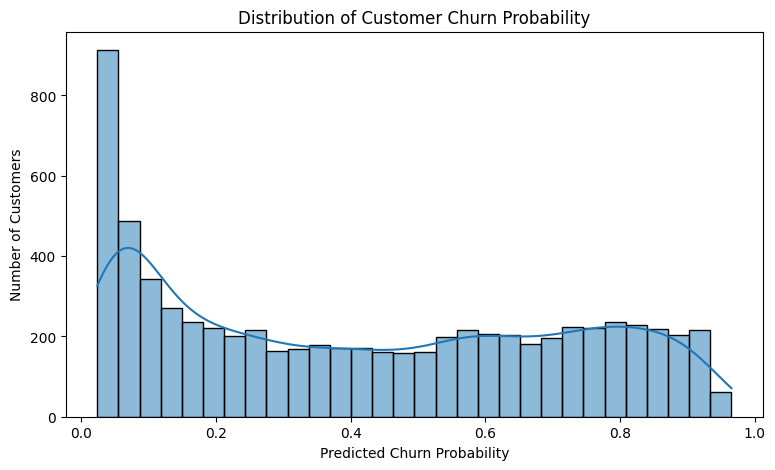

In [17]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data["Churn_Probability"],
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Churn Probability")
plt.xlabel("Predicted Churn Probability")
plt.ylabel("Number of Customers")

plt.show()

In [16]:
print(
    data["Churn_Probability"].describe()
)

count    7032.000000
mean        0.417120
std         0.297191
min         0.023710
25%         0.119499
50%         0.392277
75%         0.690164
max         0.965432
Name: Churn_Probability, dtype: float64


In [15]:
data["Churn_Probability"] = (
    best_model.predict_proba(X)[:, 1]
)

print(
    data[
        [
            "customerID",
            "Churn_Probability"
        ]
    ].head(10)
)

   customerID  Churn_Probability
0  7590-VHVEG           0.866724
1  5575-GNVDE           0.103872
2  3668-QPYBK           0.663684
3  7795-CFOCW           0.117554
4  9237-HQITU           0.848496
5  9305-CDSKC           0.932988
6  1452-KIOVK           0.674472
7  6713-OKOMC           0.412655
8  7892-POOKP           0.788629
9  6388-TABGU           0.072069


In [14]:
X = X.reindex(
    columns=feature_columns,
    fill_value=0
)

print("Final feature matrix shape:", X.shape)

Final feature matrix shape: (7032, 38)


In [13]:
import json

with open(
    "../outputs/model_features.json",
    "r"
) as f:
    feature_columns = json.load(f)

print("Number of model features:", len(feature_columns))

Number of model features: 38


In [10]:
X_raw = data.drop(
    columns=[
        "customerID",
        "Churn",
        "Churn_Target"
    ],
    errors="ignore"
)

X = pd.get_dummies(
    X_raw,
    drop_first=True
)

X = X.fillna(
    X.median(numeric_only=True)
)

X = X.fillna(0)

print("Feature matrix shape:", X.shape)

Feature matrix shape: (7032, 38)


In [9]:
model_path = "../outputs/best_xgboost_model.pkl"

best_model = joblib.load(model_path)

print("Best XGBoost model loaded successfully!")
print(best_model)

Best XGBoost model loaded successfully!
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)


In [8]:
data = pd.read_csv(
    "../data/processed/customer_master.csv"
)

print("Dataset shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

Dataset shape: (7032, 27)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Target', 'Tenure_Group', 'Service_Count', 'Estimated_Billed_Value', 'Charge_per_Tenure_Month', 'Streaming_Adoption']


In [7]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

print("Imports successful!")

Imports successful!
